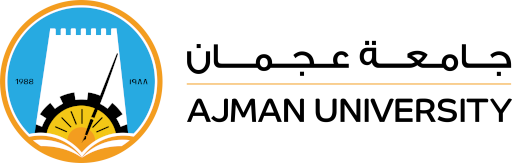

<p>
College: Engineering and Information Technology<br>
Department: Information Technology<br>
Program: Artificial Intelligence<br>
Academic Semester: Fall 2025-2026<br>
Course: BAI211 AI Fundamentals Lab<br>
Course Instructor: Prof. Mohammed Al-Betar<br>
</p></center>

Student ID: ______202411435_<br />
Student Name: ____Bibi Ekhkla Hashimi____

# **Lab 12 - Intelligent Learning Agents**

## Q-Learning

Q-learning is a model-free reinforcement learning algorithm used to teach an agent how to act optimally in an environment.
It learns the best action to take in each state by interacting with the environment — without needing to know how the environment works in advance.

Think of Q-learning like a student learning from trial and error:
each time it tries something, it gets feedback (reward or penalty) and remembers which choices led to the best outcomes — eventually becoming an expert in decision-making.


Now let's look at an example of a robot in a maze. At each step, it can move up, down, left, or right. The robot starts from a point (S) in the maze and can move on to cells that are unobstructed (.). There are some obstacles (X) in the maze which the robot should avoid. The goal is to reach the point (D).

```
S . . . .
. X X . .
. . . . .
. X . X .
. . . . D
```

If it reaches the goal → it gets +100 reward.

If it hits a wall → it gets −10 penalty.

If it moves normally → it gets −1 (small cost).

Over time, it learns which moves lead to high rewards and which moves lead to penalties. It doesn’t need prior knowledge of the maze layout — only experience.

It learns a Q-value (Quality) for each (state, action) pair:

$Q(s,a)=$ expected future reward if we take action $a$ in state $s$


Each time the agent takes an action, it updates its Q-value using:

$Q(s,a)=Q(s,a) + \alpha[r + \gamma \cdot max_{a'} Q(s', a') - Q(s, a)]$

Where:

| Symbol | Meaning |
| -------- | ------- |
| $s$ | current state |
| $a$ | current action |
| $r$ | reward received after taking action $a$ |
| $s'$ |  next state |
| $\alpha$ | learning rate (how quickly new info replaces old) |
|  $\gamma$ | discount factor (how much we value future rewards) |
| $max_{⁡a'} Q(s',a')$ | best predicted future value from next state |

### Procedure for the Q-learning algorithm:

- Observe current state $s$.
- Select an action $a$ (using exploration, e.g., $\epsilon$-greedy).
- Execute the action → observe reward $r$ and next state $s'$.
- Update Q-value using the formula above.
- Repeat until the environment is learned.

Over many episodes, $Q(s,a)$ values converge to the optimal policy — meaning the agent learns what to do in every situation.

## Question
A warehouse robot’s job is to pick up packages from storage and deliver them to the correct delivery station in the warehouse. Initially, the robot doesn’t know the most efficient routes to reach delivery zones. Over time, it learns which paths are faster and less costly by using trial and feedback (reinforcement learning).

The warehouse is represented as a 5×5 grid. Each grid cell can be:
- S → Start position (where the robot begins)
- D → Delivery zone (goal)
- X → Obstacle (wall)
- . → Empty path (free to move)

Example grid:

```
S . . . .
. X X . .
. . . . .
. X . X .
. . . . D
```


The robot (Learning Agent) starts without knowing which moves are best. It moves Up, Down, Left, or Right.

Each move gives a reward:
- +100 → reaching the delivery zone (goal)
- -10 → hitting a wall or obstacle
- -1 → any normal move (energy cost)

The agent learns using the Q-learning algorithm, updating a Q-table over multiple episodes.

Implement a Learning Agent that uses the Q-learning algorithm to find the most efficient delivery route for the robot.


In [3]:
import numpy as np
import random

# ------------------------------
# Warehouse environment setup
# ------------------------------

# Define a 5x5 grid environment
grid=[['S','.','.','.','.'],
       ['.','X','X','.','.'],
       ['.','.','.','.','.'],
       ['.','X','.','X','.'],
       ['.','.','.','.','D']]

# Define rewards for each cell type
def get_reward(current_cell):
     # goal reached
    if current_cell == 'D':
        return 100
        # obstacle
    elif current_cell =='X':
        return -10
        # normal move cost
    else:
        return -1

# ------------------------------
# Q-Learning setup
# ------------------------------

rows=5
columns=5
actions=['up','down','left','right']
# Q-table
q=np.zeros((rows,columns,len(actions)))

# Learning parameters
# learning rate
alpha=0.1
# discount factor
gamma=0.9
# exploration rate
epsilon=0.2
episodes=100
# Helper: Get next position given an action
def next_position(row,column,action):
  new_row,new_column=row,column
  if action=='up' and row>0:
    row-=1
  elif action=='down' and row<rows-1:
    row+=1
  elif action=='left' and column>0:
    column-=1
  elif action=='right' and column<columns-1:
    column+=1
  return row,column

# Helper: Find start position
def find_start():
  for i in range(rows):
    for j in range(columns):
      if grid[i][j]=='S':
        return i,j
  return -1, -1
# ------------------------------
# Training the Learning Agent
# ------------------------------
for episode in range(episodes):
    # Reset the environment
    row,column=find_start()
    total_reward=0

    # limit steps per episode
    for step in range(100):
      if random.uniform(0,1)<epsilon:
        action_index=random.randint(0,len(actions)-1)
      else:
        action_index=np.argmax(q[row,column])

      action=actions[action_index]
      new_row,new_column=next_position(row,column,action)
      cell=grid[new_row][new_column]
      reward= get_reward(cell)
        # Choose action (epsilon-greedy)

        # Q-learning formula
      old_value=q[row,column,action_index]
      next_max=np.max(q[new_row,new_column])
      new_value=old_value + alpha * (reward + gamma * next_max - old_value)
      q[row,column,action_index]=new_value
      total_reward+=reward
        # Move to next state
      row,column=new_row,new_column
        # Stop if goal is reached
      if cell == 'D':
        break
# ------------------------------
# Testing learned policy
# ------------------------------
row,column=find_start()
path=[(row,column)]

for _ in range(100):
  action_index=np.argmax(q[row,column])
  action=actions[action_index]
  row,column=next_position(row,column,action)
  path.append((row,column))
  if grid[row][column]=='D':
    break

print("Learned path: ",path)

grid=[['S','.','.','.','.'],
       ['.','X','X','.','.'],
       ['.','.','.','.','.'],
       ['.','X','.','X','.'],
       ['.','.','.','.','D']]

Learned path:  [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]
